# MCP-IPI-Guard — Guard Classifier Training + Leave-One-Out Study (v2)

## 1. Install dependencies

In [1]:
!pip install -q "transformers>=4.41" "datasets>=2.19" "accelerate>=0.30" \
    scikit-learn matplotlib pandas sentencepiece

!pip uninstall -y torchvision -q


## 2. Confirm GPU is available

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("bf16 supported:", torch.cuda.is_bf16_supported())
else:
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> GPU, then re-run.")


CUDA available: True
Device: NVIDIA A100-SXM4-40GB
bf16 supported: True


## 3. Upload data.zip and unzip


In [3]:
import os, zipfile
from google.colab import files

os.makedirs("/content/data", exist_ok=True)
print("Select data.zip:")
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith(".zip"):
        with zipfile.ZipFile(fname, "r") as z:
            z.extractall("/content/data")
        print(f"Extracted {fname} into /content/data")

print("\nContents of /content/data:")
for root, dirs, fs in os.walk("/content/data"):
    for f in fs:
        print(os.path.join(root, f))

expected = {"train.jsonl", "val.jsonl", "test.jsonl"}
present = set(os.listdir("/content/data"))
missing = expected - present
loo_present = os.path.isdir("/content/data/loo")
if missing or not loo_present:
    print(f"\nWARNING: missing {missing}, loo folder present: {loo_present}. Re-check your zip.")
else:
    print("\nAll expected files present. Continue to the next cell.")


Select data.zip:


Saving data.zip to data.zip
Extracted data.zip into /content/data

Contents of /content/data:
/content/data/val.jsonl
/content/data/test.jsonl
/content/data/train.jsonl
/content/data/loo/Financial Harm__train.jsonl
/content/data/loo/chained_multistep__test.jsonl
/content/data/loo/instruction_override__train.jsonl
/content/data/loo/tool_name_confusion__train.jsonl
/content/data/loo/agentdojo_workspace__train.jsonl
/content/data/loo/resource_uri_spoofing__test.jsonl
/content/data/loo/Others__test.jsonl
/content/data/loo/Financial Data__train.jsonl
/content/data/loo/Physical Data__train.jsonl
/content/data/loo/Others__train.jsonl
/content/data/loo/Financial Data__test.jsonl
/content/data/loo/chained_multistep__train.jsonl
/content/data/loo/jailbreak_escalation__train.jsonl
/content/data/loo/instruction_override__test.jsonl
/content/data/loo/Physical Harm__test.jsonl
/content/data/loo/Physical Data__test.jsonl
/content/data/loo/agentdojo_travel__test.jsonl
/content/data/loo/Data Security H

## 4. Load the main split and check label balance

In [4]:
import json
from collections import Counter

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

train_records = load_jsonl("/content/data/train.jsonl")
val_records   = load_jsonl("/content/data/val.jsonl")
test_records  = load_jsonl("/content/data/test.jsonl")

print(f"train: {len(train_records)}  val: {len(val_records)}  test: {len(test_records)}")

train_labels = Counter(r["label"] for r in train_records)
print(f"train label balance: benign={train_labels[0]}  attack={train_labels[1]}  "
      f"({100*train_labels[1]/len(train_records):.1f}% attack)")


train: 6319  val: 1354  test: 1356
train label balance: benign=5335  attack=984  (15.6% attack)


## 5. Compute class weights (sqrt-scaled)

Raw inverse-frequency weighting (~3.2x) destabilized DeBERTa training
(loss diverged to NaN). Square-root scaling is gentler while still
correcting for the imbalance, and is combined with a weighted sampler
(Step 8) that balances batches directly — belt and suspenders.


In [5]:
n_total = len(train_records)
n_benign = train_labels[0]
n_attack = train_labels[1]

weight_benign = (n_total / (2 * n_benign)) ** 0.5
weight_attack = (n_total / (2 * n_attack)) ** 0.5
class_weights = torch.tensor([weight_benign, weight_attack], dtype=torch.float)

print(f"Class weights (sqrt-scaled) -> benign(0): {weight_benign:.4f}  attack(1): {weight_attack:.4f}")


Class weights (sqrt-scaled) -> benign(0): 0.7696  attack(1): 1.7919


## 6. Backbone model choice + tokenizer



In [6]:
MODEL_NAME = "bert-base-uncased"
# MODEL_NAME = "microsoft/deberta-v3-base"  # uncomment to re-attempt, with dynamic padding below

MAX_LENGTH = 256  # covers the corpus's typical text length without excessive padding

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Using {MODEL_NAME}, is_fast={tokenizer.is_fast}")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Using bert-base-uncased, is_fast=True


## 7. Tokenize (dynamic padding via data collator, not fixed-length)

Uses `DataCollatorWithPadding` so each batch pads only to its own longest
example, instead of padding every example to a fixed 512 — cheaper, and
was the one untested lead if you revisit DeBERTa-v3 later.


In [7]:
from datasets import Dataset
from transformers import DataCollatorWithPadding

def to_hf_dataset(records):
    return Dataset.from_dict({
        "text": [r["text"] for r in records],
        "label": [r["label"] for r in records],
    })

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

def prepare_dataset(records):
    ds = to_hf_dataset(records)
    ds = ds.map(tokenize_fn, batched=True)
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    return ds

train_ds = prepare_dataset(train_records)
val_ds = prepare_dataset(val_records)
test_ds = prepare_dataset(test_records)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization done.")


Map:   0%|          | 0/6319 [00:00<?, ? examples/s]

Map:   0%|          | 0/1354 [00:00<?, ? examples/s]

Map:   0%|          | 0/1356 [00:00<?, ? examples/s]

Tokenization done.


## 8. Load the model

In [8]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 9. Weighted-loss Trainer + balanced batch sampler

Two complementary imbalance fixes: loss weighting (Step 5) penalizes
getting an attack wrong more heavily; the sampler below additionally
reshuffles which examples appear per batch so attacks show up more often
than their natural ~16% rate — loss weighting alone previously wasn't
enough to escape a majority-class collapse.


In [9]:
from transformers import Trainer
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        train_labels_list = self.train_dataset["label"]
        sample_weights = [class_weights[int(l)].item() for l in train_labels_list]
        sampler = WeightedRandomSampler(
            weights=sample_weights, num_samples=len(sample_weights), replacement=True
        )
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
        )


## 10. Metrics — accuracy, precision, recall, F1, ROC-AUC

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except ValueError:
        auc = float("nan")

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "roc_auc": auc}


## 11. Training arguments and main-split training run

Settings below (2e-5, 5 epochs, sqrt weights, weighted sampler) are the
configuration that produced a clean, fully-learning result in testing.


In [11]:
from transformers import TrainingArguments

bf16_supported = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir="/content/guard-checkpoint",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    max_grad_norm=1.0,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=25,
    report_to="none",
    bf16=bf16_supported,
    fp16=False,  # DeBERTa-v3 is unstable under fp16 — irrelevant for BERT but harmless to keep
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(train_result.metrics)

if any(v != v for v in train_result.metrics.values() if isinstance(v, float)):
    print("\nWARNING: NaN detected — reload a fresh model (Step 8), lower learning_rate, and retry.")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.000371,0.003900,0.999261,0.995283,1.000000,0.997636,1.000000
2,0.000119,0.000068,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.000065,0.000051,1.000000,1.000000,1.000000,1.000000,1.000000
4,0.000048,0.000044,1.000000,1.000000,1.000000,1.000000,1.000000
5,0.000044,0.000045,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

{'train_runtime': 103.7292, 'train_samples_per_second': 304.591, 'train_steps_per_second': 19.04, 'total_flos': 2317846008867120.0, 'train_loss': 0.019840274902319984, 'epoch': 5.0}


## 12. Evaluate on the held-out test set

In [12]:
test_metrics = trainer.evaluate(test_ds)
print("Test set metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.000044,0.000057,5,1.000000,1.000000,1.000000,1.000000,1.000000


Test set metrics:
  eval_loss: 5.65677291888278e-05
  eval_accuracy: 1.0
  eval_precision: 1.0
  eval_recall: 1.0
  eval_f1: 1.0
  eval_roc_auc: 1.0


## 13. Confusion matrix and ROC curve


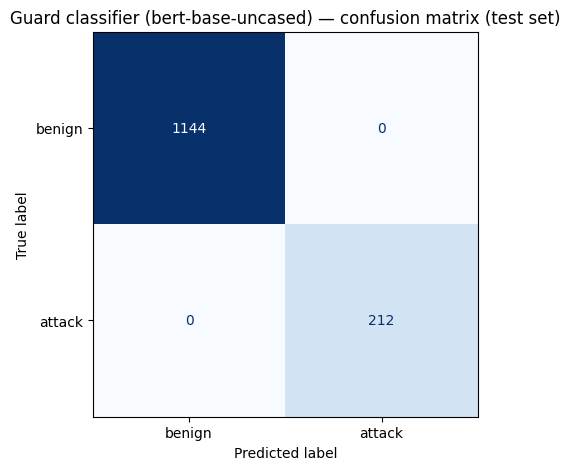

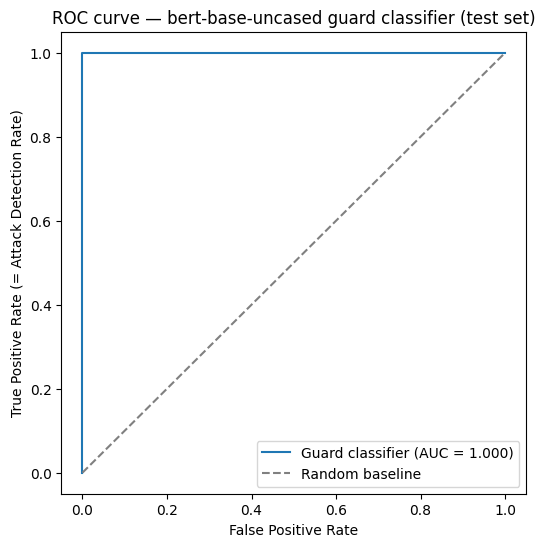

Test AUC: 1.0000


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay

predictions = trainer.predict(test_ds)
logits = predictions.predictions
labels = predictions.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
preds = np.argmax(logits, axis=-1)

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "attack"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Guard classifier ({MODEL_NAME}) — confusion matrix (test set)")
plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

fpr, tpr, thresholds = roc_curve(labels, probs[:, 1])
auc_score = roc_auc_score(labels, probs[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Guard classifier (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (= Attack Detection Rate)")
plt.title(f"ROC curve — {MODEL_NAME} guard classifier (test set)")
plt.legend()
plt.savefig("/content/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Test AUC: {auc_score:.4f}")


## 14. Per-category breakdown on the main test set

A quick preview before the full leave-one-out study below — same-category
detection rate, not generalisation to unseen categories.


In [14]:
import pandas as pd

test_df = pd.DataFrame(test_records)
test_df["pred"] = preds
test_df["correct"] = (test_df["label"] == test_df["pred"])

attack_only = test_df[test_df["label"] == 1]
category_accuracy = attack_only.groupby("attack_category")["correct"].agg(["mean", "count"])
category_accuracy.columns = ["detection_rate", "n_samples"]
category_accuracy = category_accuracy.sort_values("detection_rate")
print(category_accuracy)


                       detection_rate  n_samples
attack_category                                 
Data Security Harm                1.0         16
Financial Data                    1.0         21
Financial Harm                    1.0         18
Others                            1.0         31
Physical Data                     1.0         35
Physical Harm                     1.0         27
agentdojo_banking                 1.0          6
agentdojo_slack                   1.0          3
agentdojo_travel                  1.0          2
agentdojo_workspace               1.0          8
chained_multistep                 1.0          6
instruction_override              1.0         13
jailbreak_escalation              1.0         17
resource_uri_spoofing             1.0          7
tool_name_confusion               1.0          2


## 15. Leave-one-category-out generalisation study


In [15]:
import os

LOO_DIR = "/content/data/loo"
LOO_EPOCHS = 2  # deliberately fewer than the main run — this is a breadth sweep, not a tuned result
LOO_CATEGORIES_TO_RUN = None  # None = run all; or e.g. ["jailbreak_escalation", "agentdojo_slack"] to test timing first

all_loo_files = sorted(f for f in os.listdir(LOO_DIR) if f.endswith("__train.jsonl"))
categories = [f.replace("__train.jsonl", "") for f in all_loo_files]
if LOO_CATEGORIES_TO_RUN is not None:
    categories = [c for c in categories if c in LOO_CATEGORIES_TO_RUN]

print(f"Will run leave-one-out for {len(categories)} categories:")
for c in categories:
    print(f"  - {c}")


Will run leave-one-out for 15 categories:
  - Data Security Harm
  - Financial Data
  - Financial Harm
  - Others
  - Physical Data
  - Physical Harm
  - agentdojo_banking
  - agentdojo_slack
  - agentdojo_travel
  - agentdojo_workspace
  - chained_multistep
  - instruction_override
  - jailbreak_escalation
  - resource_uri_spoofing
  - tool_name_confusion


In [16]:
def run_one_loo_fold(category):
    train_path = f"{LOO_DIR}/{category}__train.jsonl"
    test_path = f"{LOO_DIR}/{category}__test.jsonl"
    fold_train_records = load_jsonl(train_path)
    fold_test_records = load_jsonl(test_path)

    fold_train_labels = Counter(r["label"] for r in fold_train_records)
    fold_n_total = len(fold_train_records)
    fold_weight_benign = (fold_n_total / (2 * fold_train_labels[0])) ** 0.5 if fold_train_labels[0] else 1.0
    fold_weight_attack = (fold_n_total / (2 * fold_train_labels[1])) ** 0.5 if fold_train_labels[1] else 1.0
    fold_class_weights = torch.tensor([fold_weight_benign, fold_weight_attack], dtype=torch.float)

    fold_train_ds = prepare_dataset(fold_train_records)
    fold_test_ds = prepare_dataset(fold_test_records)

    fold_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    class FoldWeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
            outputs = model(**inputs)
            loss_fct = nn.CrossEntropyLoss(weight=fold_class_weights.to(outputs.logits.device))
            loss = loss_fct(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

        def get_train_dataloader(self):
            labels_list = self.train_dataset["label"]
            weights = [fold_class_weights[int(l)].item() for l in labels_list]
            sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)
            return DataLoader(self.train_dataset, batch_size=self.args.per_device_train_batch_size,
                               sampler=sampler, collate_fn=self.data_collator)

    fold_args = TrainingArguments(
        output_dir=f"/content/loo-checkpoint/{category}",
        eval_strategy="no",
        save_strategy="no",
        num_train_epochs=LOO_EPOCHS,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        max_grad_norm=1.0,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=100,
        report_to="none",
        bf16=bf16_supported,
        fp16=False,
    )

    fold_trainer = FoldWeightedTrainer(
        model=fold_model, args=fold_args, train_dataset=fold_train_ds,
        data_collator=data_collator, compute_metrics=compute_metrics,
    )
    fold_trainer.train()

    fold_predictions = fold_trainer.predict(fold_test_ds)
    fold_logits = fold_predictions.predictions
    fold_labels = fold_predictions.label_ids
    fold_preds = np.argmax(fold_logits, axis=-1)
    fold_probs = torch.softmax(torch.tensor(fold_logits), dim=-1).numpy()

    is_attack = fold_labels == 1
    is_benign = fold_labels == 0
    detection_rate = (fold_preds[is_attack] == 1).mean() if is_attack.sum() else float("nan")
    false_positive_rate = (fold_preds[is_benign] == 1).mean() if is_benign.sum() else float("nan")
    try:
        fold_auc = roc_auc_score(fold_labels, fold_probs[:, 1])
    except ValueError:
        fold_auc = float("nan")

    del fold_model, fold_trainer
    torch.cuda.empty_cache()

    return {
        "held_out_category": category,
        "n_attack_test": int(is_attack.sum()),
        "n_benign_test": int(is_benign.sum()),
        "detection_rate": detection_rate,
        "false_positive_rate": false_positive_rate,
        "auc": fold_auc,
    }


In [17]:
loo_results = []
for i, category in enumerate(categories):
    print(f"\n=== [{i+1}/{len(categories)}] Leave-one-out: {category} ===")
    result = run_one_loo_fold(category)
    print(result)
    loo_results.append(result)

loo_df = pd.DataFrame(loo_results).sort_values("detection_rate")
loo_df.to_csv("/content/leave_one_out_results.csv", index=False)
print("\n=== Full leave-one-out results ===")
print(loo_df.to_string(index=False))



=== [1/15] Leave-one-out: Data Security Harm ===


Map:   0%|          | 0/8842 [00:00<?, ? examples/s]

Map:   0%|          | 0/7809 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

...

Map:   0%|          | 0/7642 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Step,Training Loss
100,0.255527
200,0.010109
300,0.009890
400,0.000464
500,0.000256
600,0.001110
700,0.000151
800,0.000134
900,0.000113
1000,0.000106


{'held_out_category': 'tool_name_confusion', 'n_attack_test': 20, 'n_benign_test': 7622, 'detection_rate': np.float64(1.0), 'false_positive_rate': np.float64(0.0), 'auc': np.float64(1.0)}

=== Full leave-one-out results ===
    held_out_category  n_attack_test  n_benign_test  detection_rate  false_positive_rate      auc
     agentdojo_travel             27           7622        0.888889             0.000000 0.999772
   Data Security Harm            187           7622        1.000000             0.000000 1.000000
       Financial Harm            153           7622        1.000000             0.000000 1.000000
       Financial Data            102           7622        1.000000             0.000000 1.000000
        Physical Data            187           7622        1.000000             0.000000 1.000000
        Physical Harm            170           7622        1.000000             0.000131 1.000000
    agentdojo_banking             51           7622        1.000000             0.000000 1

## 16. Leave-one-out results plot (generalisation table for your dissertation)

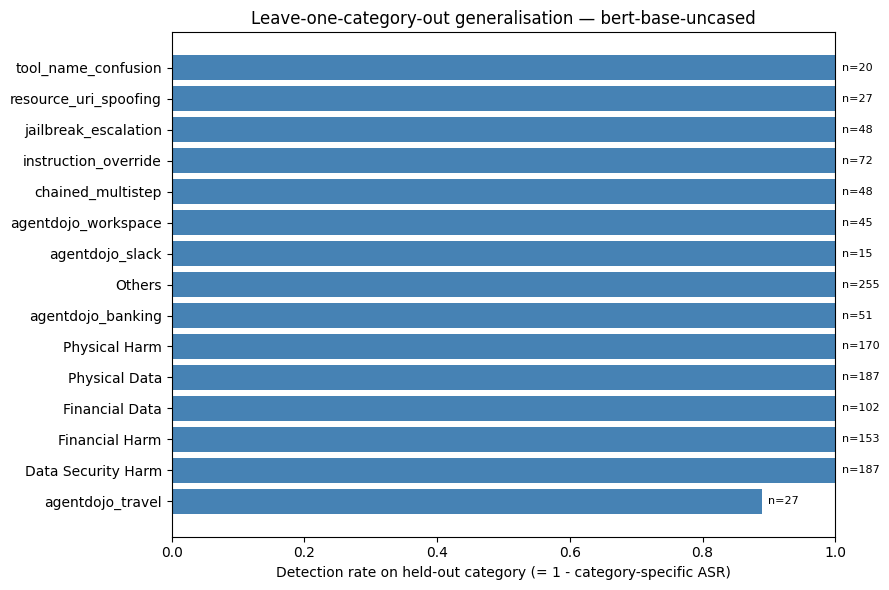


Categories with the fewest test examples have the noisiest estimates — treat those detection rates as rougher signals, not precise numbers, and say so if you report them (your proposal already plans bootstrap 95% CIs for the full generalisation study — this run is a first pass).


In [18]:
fig, ax = plt.subplots(figsize=(9, max(4, len(loo_df) * 0.4)))
ax.barh(loo_df["held_out_category"], loo_df["detection_rate"], color="steelblue")
ax.set_xlabel("Detection rate on held-out category (= 1 - category-specific ASR)")
ax.set_title(f"Leave-one-category-out generalisation — {MODEL_NAME}")
ax.set_xlim(0, 1)
for i, (rate, n) in enumerate(zip(loo_df["detection_rate"], loo_df["n_attack_test"])):
    ax.text(rate + 0.01, i, f"n={n}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("/content/leave_one_out_plot.png", dpi=150, bbox_inches="tight")
plt.show()



## 17. Save everything and download

Downloads the main checkpoint, both plots, and the leave-one-out results
CSV in one zip.


In [20]:
trainer.save_model("/content/guard-checkpoint/final")
tokenizer.save_pretrained("/content/guard-checkpoint/final")

import shutil
os.makedirs("/content/deliverables", exist_ok=True)
shutil.copy("/content/confusion_matrix.png", "/content/deliverables/")
shutil.copy("/content/roc_curve.png", "/content/deliverables/")
shutil.copy("/content/leave_one_out_plot.png", "/content/deliverables/")
shutil.copy("/content/leave_one_out_results.csv", "/content/deliverables/")
shutil.copytree("/content/guard-checkpoint/final", "/content/deliverables/guard-checkpoint-final")

shutil.make_archive("/content/mcp-ipi-guard-training-results", "zip", "/content/deliverables")

from google.colab import files
files.download("/content/mcp-ipi-guard-training-results.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FileExistsError: [Errno 17] File exists: '/content/deliverables/guard-checkpoint-final'

### Optional: push the checkpoint to Hugging Face Hub

For connecting to the FastAPI backend's `GUARD_MODEL_PATH` without manual
file copying.


In [ ]:
# from huggingface_hub import login
# login()
#
# HUB_REPO_ID = "your-username/mcp-ipi-guard-guard-classifier"
# trainer.model.push_to_hub(HUB_REPO_ID)
# tokenizer.push_to_hub(HUB_REPO_ID)
# print(f"Set GUARD_MODEL_PATH={HUB_REPO_ID} in the FastAPI backend's .env to use it.")
